 in a # Overlayed Quadratic Grids (Cell Lengths 1.0 and 0.45)

This notebook generates an image with two overlaid quadratic grids, highlights selected cells, and exports both PNG and PDF.

In [104]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def draw_overlayed_grids(output_dir: Path) -> tuple[Path, Path]:
    # Domain bounds chosen so both 1.0 and 0.45 cell grids align cleanly in view.
    x_min, x_max = -2.0, 2.0
    y_min, y_max = -2.0, 2.0

    fig, ax = plt.subplots(figsize=(6.2, 6.2), dpi=300)

    # Base grid: cell length 1.0 (solid black lines).
    major = 1.0
    xs_major = [x_min + i * major for i in range(int((x_max - x_min) / major) + 1)]
    ys_major = [y_min + i * major for i in range(int((y_max - y_min) / major) + 1)]
    for x in xs_major:
        ax.plot([x, x], [y_min, y_max], color="black", linewidth=1.2, zorder=3)
    for y in ys_major:
        ax.plot([x_min, x_max], [y, y], color="black", linewidth=1.2, zorder=3)

    # Overlay grid: cell length 0.45 (dashed dark-gray lines).
    minor = 0.45
    num_minor_x = int(round((x_max - x_min) / minor))
    num_minor_y = int(round((y_max - y_min) / minor))
    xs_minor = [x_min + i * minor for i in range(num_minor_x + 1)]
    ys_minor = [y_min + i * minor for i in range(num_minor_y + 1)]
    for x in xs_minor:
        ax.plot([x, x], [y_min, y_max], color="#4b4b4b", linewidth=0.9, linestyle=(0, (5, 5)), zorder=2)
    for y in ys_minor:
        ax.plot([x_min, x_max], [y, y], color="#4b4b4b", linewidth=0.9, linestyle=(0, (5, 5)), zorder=2)

    # Color selected major-grid corner cells (blue).
    colored_major_cells = [
        (-2, 1, "#b9b7f3"),
        (1, 1, "#b9b7f3"),
        (-2, -2, "#b9b7f3"),
        (1, -2, "#b9b7f3"),
    ]
    for x0, y0, color in colored_major_cells:
        rect = Rectangle((x0, y0), 1.0, 1.0, facecolor=color, edgecolor="none", alpha=0.75, zorder=1)
        ax.add_patch(rect)

    # Highlight one middle lower-level (small-grid) cell in the second row in pink, shifted up by 2 small cells.
    pink_x, pink_y = -0.2, 1.15
    pink_minor_cell = Rectangle((pink_x, pink_y), minor, minor, facecolor="#f8c5c5", edgecolor="none", alpha=0.75, zorder=1.5)
    ax.add_patch(pink_minor_cell)

    # Epsilon for arrow tips to avoid overlap with lines
    epsilon = 0.02

    # Mark the width of the pink square as "a" below the pink cell.
    y_dim_a = pink_y - 0.08
    ax.annotate(
        "",
        xy=(pink_x - epsilon, y_dim_a),
        xytext=(pink_x + minor + epsilon, y_dim_a),
        arrowprops=dict(arrowstyle="<->", color="#cc3333", linewidth=1.8),
        zorder=5,
    )
    ax.text(
        pink_x + minor / 2.0 + 0.05,
        y_dim_a - 0.054,
        "a",
        color="#cc3333",
        fontsize=14,
        ha="center",
        va="top",
        zorder=5,
    )

    # Mark the width of one blue major cell as "b" in the same style, placed below the blue cell.
    blue_x0 = -2.0
    blue_width = 1.0
    y_dim_b = 0.88
    ax.annotate(
        "",
        xy=(blue_x0 , y_dim_b),
        xytext=(blue_x0 + blue_width - epsilon, y_dim_b),
        arrowprops=dict(arrowstyle="<->", color="#3a5ee8", linewidth=1.8),
        zorder=5,
    )
    ax.text(
        blue_x0 + blue_width / 2.0+0.02,
        y_dim_b - 0.04+0.01,
        "b",
        color="#3a5ee8",
        fontsize=14,
        ha="center",
        va="top",
        zorder=5,
    )

    # Draw horizontal red lines of length (1.0 + 0.45) / 2 from top corner blue cells toward the center.
    line_length = (1.0 + minor) / 2.0
    y_line = 1.5
    x_left_start = -1.0  # Right edge of top-left blue box spanning x in [-2, -1].
    x_right_start = 1.0  # Left edge of top-right blue box spanning x in [1, 2].
    x_left_end = x_left_start + line_length
    x_right_end = x_right_start - line_length
    ax.plot([x_left_start, x_left_end], [y_line, y_line], color="#ff3b3b", linewidth=2.0, zorder=4)
    ax.plot([x_right_start, x_right_end], [y_line, y_line], color="#ff3b3b", linewidth=2.0, zorder=4)
    ax.text((x_left_start + x_left_end-0.05) / 2.0, y_line -0.3+ 0.1, "$I_{12}$", color="#ff3b3b", fontsize=13, ha="center", va="bottom", zorder=5)
    ax.text((x_right_end + x_right_start-0.24) / 2.0, y_line -0.3 + 0.1, "$I_{12}$", color="#ff3b3b", fontsize=13, ha="center", va="bottom", zorder=5)

    # Add short vertical end caps only at the inner ends (not where lines touch blue cells).
    cap_half_height = 0.10
    cap_positions = [x_left_end, x_right_end]
    for x_cap in cap_positions:
        ax.plot([x_cap, x_cap], [y_line - cap_half_height, y_line + cap_half_height], color="#ff3b3b", linewidth=2.0, zorder=4)

    # Draw a green double-headed arrow connecting the red bars, with arrow tips touching the red vertical bars.
    ax.annotate(
        "",
        xy=(x_left_end - epsilon, y_line),
        xytext=(x_right_end + epsilon, y_line),
        arrowprops=dict(arrowstyle="<->", color="#00b894", linewidth=2.2),
        zorder=6,
    )
    # Place 'x' label at the same height, vertically aligned with 'a', not bold or large.
    x_a_center = pink_x + minor / 2.0 + 0.10
    ax.text(x_a_center, y_line + 0.08, "x", color="#00b894", fontsize=14, ha="center", va="bottom", zorder=7)

    # Show only the top half of the picture.
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0.0, y_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#ececec")

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("black")

    output_dir.mkdir(parents=True, exist_ok=True)
    png_path = output_dir / "colorProblemSolved.png"
    pdf_path = output_dir / "colorProblemSolved.pdf"

    fig.savefig(png_path, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    return png_path, pdf_path

Created PNG: /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/colorProblemSolved.png
Created PDF: /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/colorProblemSolved.pdf


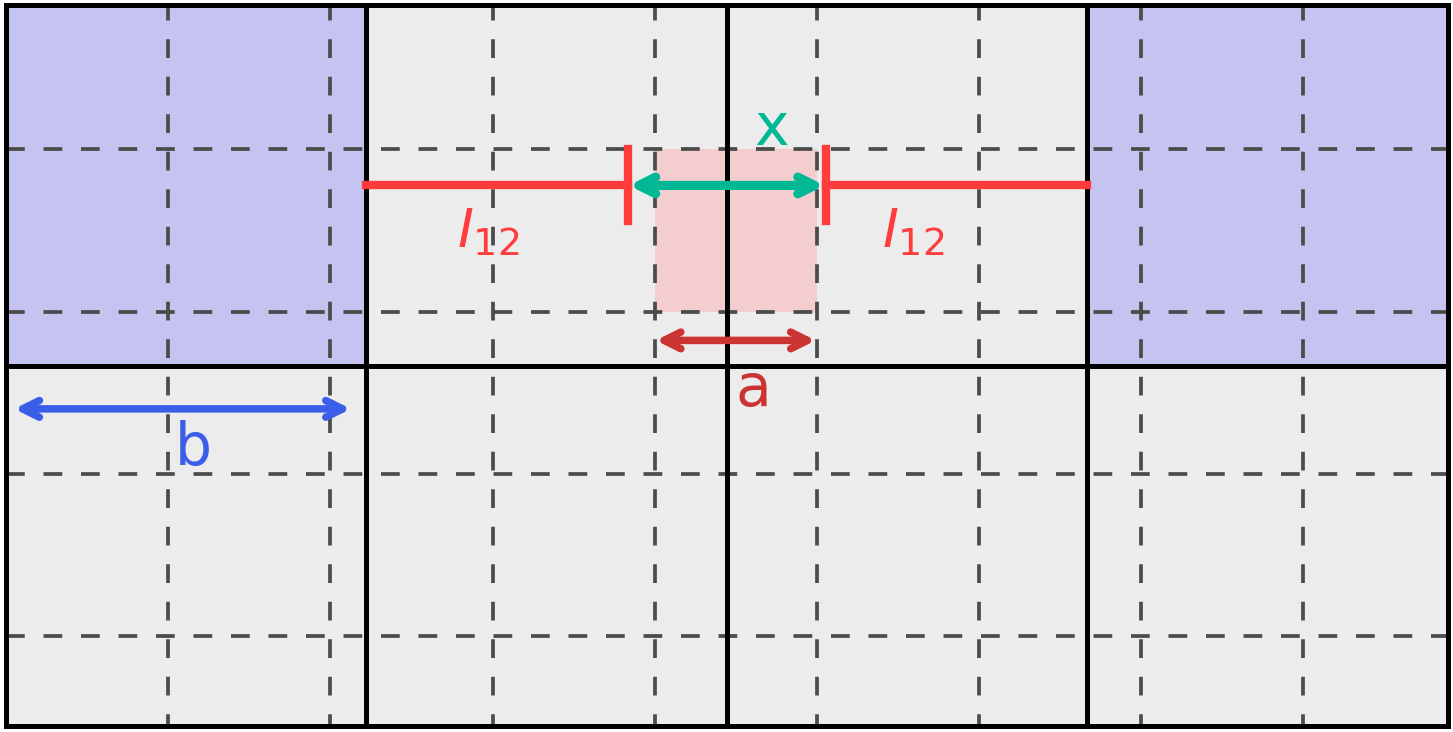

In [105]:
from IPython.display import Image, display

output_dir = Path.cwd() / "thesis_plots"
png_path, pdf_path = draw_overlayed_grids(output_dir)

print(f"Created PNG: {png_path}")
print(f"Created PDF: {pdf_path}")
display(Image(filename=str(png_path)))

Show nice picture for hgc08 decomposition

Created PNG: /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/csfAdvantage.png
Created PDF: /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/csfAdvantage.pdf


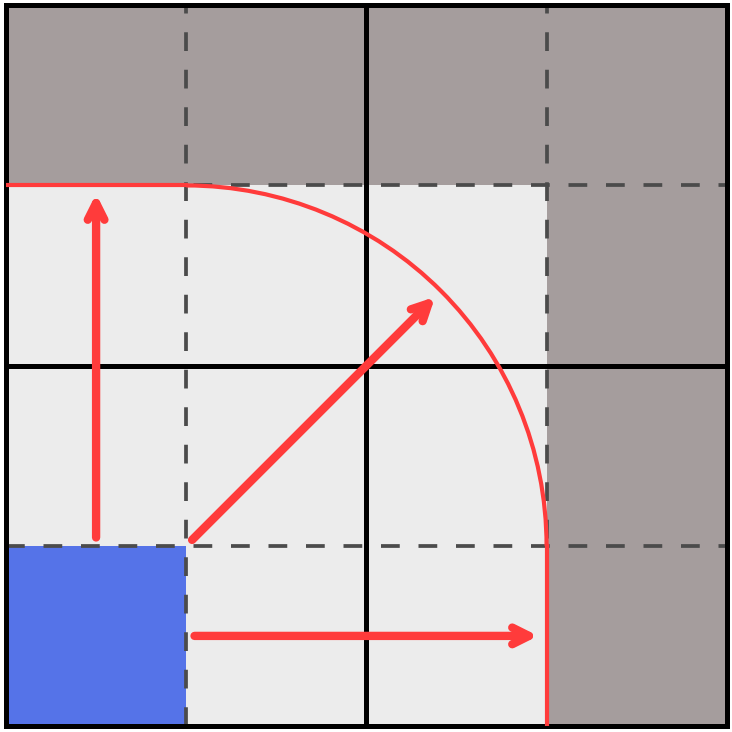

In [106]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Rectangle
import math

def draw_half_grid_overlay(output_dir: Path) -> tuple[Path, Path]:
    # Domain bounds chosen so both 1.0 and 0.5 cell grids align cleanly in view.
    x_min, x_max = -2.0, 0.0  # Only show the left half
    y_min, y_max = -0, 2.0

    fig, ax = plt.subplots(figsize=(3.1, 6.2), dpi=300)  # Half width

    # Base grid: cell length 1.0 (solid black lines).
    major = 1.0
    xs_major = [x_min + i * major for i in range(int((x_max - x_min) / major) + 1)]
    ys_major = [y_min + i * major for i in range(int((y_max - y_min) / major) + 1)]
    for x in xs_major:
        ax.plot([x, x], [y_min, y_max], color="black", linewidth=1.2, zorder=3)
    for y in ys_major:
        ax.plot([x_min, x_max], [y, y], color="black", linewidth=1.2, zorder=3)

    # Overlay grid: cell length 0.5 (dashed dark-gray lines).
    minor = 0.5
    num_minor_x = int(round((x_max - x_min) / minor))
    num_minor_y = int(round((y_max - y_min) / minor))
    xs_minor = [x_min + i * minor for i in range(num_minor_x + 1)]
    ys_minor = [y_min + i * minor for i in range(num_minor_y + 1)]
    for x in xs_minor:
        ax.plot([x, x], [y_min, y_max], color="#4b4b4b", linewidth=0.9, linestyle=(0, (5, 5)), zorder=2)
    for y in ys_minor:
        ax.plot([x_min, x_max], [y, y], color="#4b4b4b", linewidth=0.9, linestyle=(0, (5, 5)), zorder=2)

    # Highlight the bottom left small cell in blue (small grid cell at (x_min, y_min)).
    blue_small_cell = Rectangle((x_min, y_min), minor, minor, facecolor="#3a5ee8", edgecolor="none", alpha=0.85, zorder=1.5)
    ax.add_patch(blue_small_cell)

    # Highlight the uppermost small cell in gray (top left).
    gray_top_cell = Rectangle((x_min, y_max - minor), 3 * minor, minor, facecolor="#8D8383", edgecolor="none", alpha=0.75, zorder=1.5)
    ax.add_patch(gray_top_cell)

    # Highlight the rightmost small cell in gray (bottom right of left half).
    gray_right_cell = Rectangle((x_max - minor, y_min), minor, 4 * minor, facecolor="#8D8383", edgecolor="none", alpha=0.75, zorder=1.5)
    ax.add_patch(gray_right_cell)

    # Mark the locus of points at Euclidean distance exactly 1 from the blue square.
    d = 1.0
    cell_x0, cell_x1 = x_min, x_min + minor
    cell_y0, cell_y1 = y_min, y_min + minor
    line_color = "#ff3b3b"
    line_width = 1.0

    # Four straight offset segments.
    ax.plot([cell_x0, cell_x1], [cell_y1 + d, cell_y1 + d], color=line_color, linewidth=line_width, zorder=3.6)
    ax.plot([cell_x0, cell_x1], [cell_y0 - d, cell_y0 - d], color=line_color, linewidth=line_width, zorder=3.6)
    ax.plot([cell_x0 - d, cell_x0 - d], [cell_y0, cell_y1], color=line_color, linewidth=line_width, zorder=3.6)
    ax.plot([cell_x1 + d, cell_x1 + d], [cell_y0, cell_y1], color=line_color, linewidth=line_width, zorder=3.6)

    # Four quarter-circle corner arcs (radius d).
    corner_arcs = [
        ((cell_x0, cell_y0), 180, 270),
        ((cell_x1, cell_y0), 270, 360),
        ((cell_x1, cell_y1), 0, 90),
        ((cell_x0, cell_y1), 90, 180),
    ]
    for (cx, cy), theta1, theta2 in corner_arcs:
        arc = Arc((cx, cy), 2 * d, 2 * d, angle=0, theta1=theta1, theta2=theta2,
                  color=line_color, linewidth=line_width, zorder=3.6)
        ax.add_patch(arc)

    # Add a red arrow of length 1 pointing upwards from the center of the blue cell, shifted up by 0.5.
    arrow_x = x_min + minor / 2.0
    arrow_y = y_min + minor
    ax.annotate(
        "",
        xy=(arrow_x, arrow_y + 1.0),
        xytext=(arrow_x, arrow_y),
        arrowprops=dict(arrowstyle="->", color="#ff3b3b", linewidth=2.0),
        zorder=4,
    )

    # Add a second red arrow of length 1 pointing right from the right edge of the blue cell.
    arrow2_x = x_min + minor
    arrow2_y = y_min + minor / 2.0
    ax.annotate(
        "",
        xy=(arrow2_x + 1.0, arrow2_y),
        xytext=(arrow2_x, arrow2_y),
        arrowprops=dict(arrowstyle="->", color="#ff3b3b", linewidth=2.0),
        zorder=4,
    )

    # Add a third red arrow of length 1 pointing to the top-right from the blue cell's top-right corner.
    diag_dx = 1.0 / math.sqrt(2.0)
    diag_dy = 1.0 / math.sqrt(2.0)
    arrow3_x = x_min + minor
    arrow3_y = y_min + minor
    ax.annotate(
        "",
        xy=(arrow3_x + diag_dx, arrow3_y + diag_dy),
        xytext=(arrow3_x, arrow3_y),
        arrowprops=dict(arrowstyle="->", color="#ff3b3b", linewidth=2.0),
        zorder=4,
    )

    # Show only the left half of the picture.
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#ececec")

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("black")

    output_dir.mkdir(parents=True, exist_ok=True)
    png_path = output_dir / "csfAdvantage.png"
    pdf_path = output_dir / "csfAdvantage.pdf"

    fig.savefig(png_path, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    return png_path, pdf_path

# Run and display the new grid
output_dir = Path.cwd() / "thesis_plots"
png_path, pdf_path = draw_half_grid_overlay(output_dir)
print(f"Created PNG: {png_path}")
print(f"Created PDF: {pdf_path}")
from IPython.display import Image, display
display(Image(filename=str(png_path)))

Created PNG: /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/hgc08.png
Created PDF: /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/hgc08.pdf


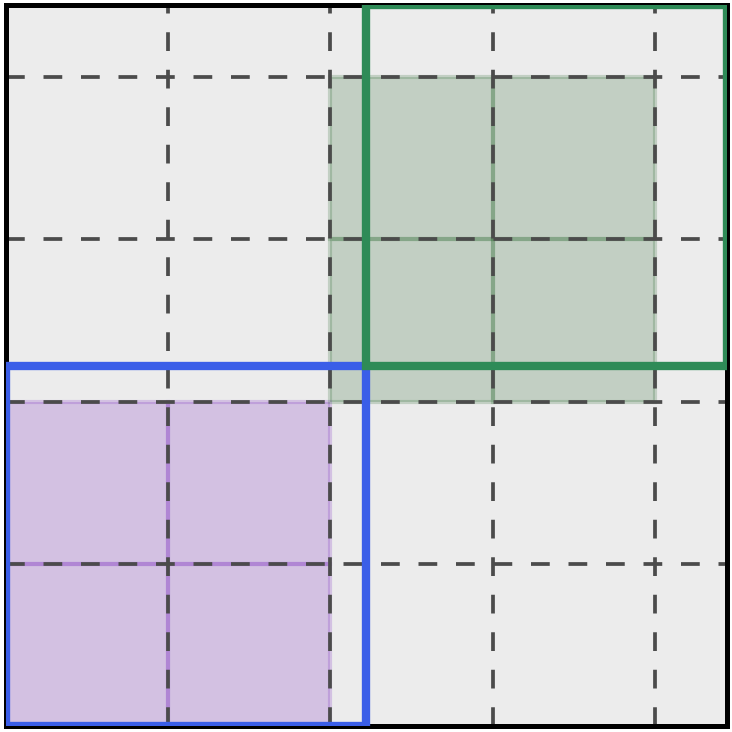

In [107]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def draw_half_grid_overlay_clean(output_dir: Path) -> tuple[Path, Path]:
    # Match the second plot dimensions exactly (left half and top half view).
    x_min, x_max = -2.0, 0.0
    y_min, y_max = 0.0, 2.0

    fig, ax = plt.subplots(figsize=(3.1, 6.2), dpi=300)

    # Base grid: cell length 1.0 (solid black lines).
    major = 1.0
    xs_major = [x_min + i * major for i in range(int((x_max - x_min) / major) + 1)]
    ys_major = [y_min + i * major for i in range(int((y_max - y_min) / major) + 1)]
    for x in xs_major:
        ax.plot([x, x], [y_min, y_max], color="black", linewidth=1.2, zorder=3)
    for y in ys_major:
        ax.plot([x_min, x_max], [y, y], color="black", linewidth=1.2, zorder=3)

    # Overlay grid: cell length 0.45 (dashed dark-gray lines).
    minor = 0.45
    num_minor_x = int(round((x_max - x_min) / minor))
    num_minor_y = int(round((y_max - y_min) / minor))
    xs_minor = [x_min + i * minor for i in range(num_minor_x + 1)]
    ys_minor = [y_min + i * minor for i in range(num_minor_y + 1)]
    for x in xs_minor:
        ax.plot([x, x], [y_min, y_max], color="#4b4b4b", linewidth=0.9, linestyle=(0, (5, 5)), zorder=2)
    for y in ys_minor:
        ax.plot([x_min, x_max], [y, y], color="#4b4b4b", linewidth=0.9, linestyle=(0, (5, 5)), zorder=2)

    # Use outline-only styling for the two large highlighted cells.
    blue_big = Rectangle((x_min, y_min), major, major, facecolor="none", edgecolor="#3a5ee8", linewidth=2.0, zorder=3.5)
    green_big = Rectangle((x_max - major, y_max - major), major, major, facecolor="none", edgecolor="#2e8b57", linewidth=2.0, zorder=3.5)
    ax.add_patch(blue_big)
    ax.add_patch(green_big)

    # Fill the bottom-left 2x2 small cells that were previously border-only purple.
    for ix in range(2):
        for iy in range(2):
            x0 = x_min + ix * minor
            y0 = y_min + iy * minor
            highlighted_cell = Rectangle(
                (x0, y0),
                minor,
                minor,
                facecolor="#7b2cbf",
                edgecolor="#7b2cbf",
                linewidth=1.0,
                alpha=0.22,
                zorder=1.2,
            )
            ax.add_patch(highlighted_cell)

    # Fill the shifted top-right 2x2 small cells that were previously border-only green.
    for ix in range(2, 4):
        for iy in range(2, 4):
            x0 = x_min + ix * minor
            y0 = y_min + iy * minor
            highlighted_cell_green = Rectangle(
                (x0, y0),
                minor,
                minor,
                facecolor="#1b5e20",
                edgecolor="#1b5e20",
                linewidth=1.0,
                alpha=0.20,
                zorder=1.2,
            )
            ax.add_patch(highlighted_cell_green)

    # Styling to match prior plot framing.
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#ececec")

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("black")

    output_dir.mkdir(parents=True, exist_ok=True)
    png_path = output_dir / "hgc08.png"
    pdf_path = output_dir / "hgc08.pdf"

    fig.savefig(png_path, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    return png_path, pdf_path

# Run and display the clean grid
output_dir = Path.cwd() / "thesis_plots"
png_path, pdf_path = draw_half_grid_overlay_clean(output_dir)
print(f"Created PNG: {png_path}")
print(f"Created PDF: {pdf_path}")
from IPython.display import Image, display
display(Image(filename=str(png_path)))